# 09 · Modelo multiclase sobre el tipo de respuesta e historial de la ruta de gestión

Diagnóstico previo (diciembre): el 91 % de los falsos positivos son ceros del tipo "no sabemos si se le ofreció", clientes que sí fueron contactados pero terminaron en un acuerdo de pago (compromiso de pago o no acepta acuerdo), no en una opción de pago. El modelo binario mezcla esas rutas en el cero.

Dos cambios, validados con los tres cortes temporales:
- **Multiclase**: predecir las cinco clases de `tipo_var_rpta_alt` y sumar las tres que son 1 (a, b, c). El archivo de Kaggle sigue siendo 0/1 con umbral en diciembre.
- **Historial de la ruta**: cuántas veces la obligación y el cliente terminaron antes en compromiso de pago, en no acepta acuerdo o en cada tipo de respuesta (solo meses anteriores a t).

1. Datos y etiquetas · 2. Variables de ruta · 3. Cuatro variantes en validación temporal · 4. Resultado y Kaggle

In [1]:
import warnings, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import lightgbm as lgb
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

warnings.filterwarnings("ignore"); pd.set_option("display.width", 200, "display.max_columns", 60)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data"; PROC = DATA / "processed"; OUT = ROOT / "outputs"; (ROOT / "models").mkdir(exist_ok=True)
C_BLUE, C_ORANGE, C_GRAY, C_MUTED = "#2a78d6", "#eb6834", "#c9c8c3", "#52514e"
mpl.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": C_GRAY, "axes.grid": True, "grid.color": "#ececea",
                     "axes.axisbelow": True, "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left", "axes.labelcolor": C_MUTED, "xtick.color": C_MUTED, "ytick.color": C_MUTED})
SEED = 42; NJ = 8; N_MESES = 13
import sys; sys.path.insert(0, str(ROOT / "src"))
from tracking import grupo, registrar_busqueda, registrar_final, anexar, resumen
TAGS = {"notebook": "09_multiclase_ruta", "validacion": "temporal_3_cortes", "particion": "train<=t-1 / val t, t in {oct,nov,dic}"}
def month_idx(yyyymm): return (yyyymm // 100 - 2023) * 12 + (yyyymm % 100 - 1)

## 1. Datos y etiquetas

Las 100 variables del 06. La etiqueta multiclase viene de `tipo_var_rpta_alt` de trtest, unida por las llaves de obligación y mes.

In [2]:
train = pd.read_parquet(PROC / "train_fe.parquet"); test = pd.read_parquet(PROC / "test_fe.parquet")
FEATS = pd.read_csv(PROC / "features_fe.csv").feature.tolist(); TARGET = "var_rpta_alt"
KEYS = ["nit_enmascarado", "num_oblig_orig_enmascarado", "num_oblig_enmascarado", "fecha_var_rpta_alt"]
raw = pd.read_csv(DATA / "prueba_op_base_pivot_var_rpta_alt_enmascarado_trtest.csv", usecols=KEYS + ["tipo_var_rpta_alt", "marca_alt_rank"], low_memory=False).drop_duplicates(KEYS)
train = train.merge(raw, on=KEYS, how="left"); assert train.tipo_var_rpta_alt.notna().all()
CLASES = ["a_uno_tipo_1", "b_uno_tipo_2", "c_uno_tipo_3", "d_cero_tipo_1", "e_cero_tipo_2"]; POS = [0, 1, 2]
train["clase"] = train.tipo_var_rpta_alt.map({c: i for i, c in enumerate(CLASES)}).astype(int)
CAT = [c for c in FEATS if str(train[c].dtype) == "category"]
for c in CAT:
    cats = pd.api.types.union_categoricals([train[c], test[c]]).categories
    train[c] = pd.Categorical(train[c], categories=cats); test[c] = pd.Categorical(test[c], categories=cats)
y = train[TARGET]; yc = train["clase"]; mes = train.fecha_var_rpta_alt
print("Distribución de clases:"); print(pd.crosstab(train.tipo_var_rpta_alt, y).assign(pct=lambda d: (d.sum(axis=1) / len(train)).round(3)))

Distribución de clases:
var_rpta_alt          0.0     1.0    pct
tipo_var_rpta_alt                       
a_uno_tipo_1            0  178548  0.314
b_uno_tipo_2            0   74702  0.131
c_uno_tipo_3            0   19518  0.034
d_cero_tipo_1       17283       0  0.030
e_cero_tipo_2      278200       0  0.490


## 2. Variables de ruta de gestión (prefijo `ruta_`)

Para cada fila en el mes t, solo con meses anteriores: cuántas veces la obligación terminó en cada tipo de respuesta y en cada resultado de gestión relevante (compromiso de pago, no acepta acuerdo, acepta alternativa), el último tipo de respuesta, y lo mismo agregado por cliente.

In [3]:
raw["t"] = month_idx(raw.fecha_var_rpta_alt)
raw["r_compromiso"] = (raw.marca_alt_rank == "Cliente compromiso de pago").astype(float); raw["r_no_acuerdo"] = (raw.marca_alt_rank == "No acepta acuerdo").astype(float)
raw["r_acepta"] = (raw.marca_alt_rank == "Acepta alternativa").astype(float); raw["r_e_cero"] = (raw.tipo_var_rpta_alt == "e_cero_tipo_2").astype(float); raw["r_d_cero"] = (raw.tipo_var_rpta_alt == "d_cero_tipo_1").astype(float)
raw["clase"] = raw.tipo_var_rpta_alt.map({c: i for i, c in enumerate(CLASES)}).astype(float)
base = pd.concat([train[KEYS + ["t"]], test[KEYS + ["t"]]], ignore_index=True); t_arr = base.t.to_numpy(); n_tr = len(train)

def to_wide(df, idx, col_t, values, n_rows):
    M = np.full((n_rows, N_MESES), np.nan); M[idx, col_t] = values; return M
def suma_previa(M, r, t):
    cs = np.concatenate([np.zeros((M.shape[0], 1)), np.nan_to_num(M).cumsum(axis=1)], axis=1); out = cs[np.clip(r, 0, None), t]; out[r < 0] = np.nan; return out
def ultimo_previo(M, r, t):
    F = pd.DataFrame(M).ffill(axis=1).to_numpy(); out = F[np.clip(r, 0, None), t - 1]; out[r < 0] = np.nan; return out

ruta = pd.DataFrame(index=base.index)
oi = pd.Index(raw.num_oblig_enmascarado.unique()); ro = oi.get_indexer(raw.num_oblig_enmascarado); r = oi.get_indexer(base.num_oblig_enmascarado)
for v in ["r_compromiso", "r_no_acuerdo", "r_acepta", "r_e_cero", "r_d_cero"]:
    M = to_wide(raw, ro, raw.t.to_numpy(), raw[v].to_numpy(), len(oi)); ruta[f"ruta_obl_n_{v[2:]}"] = suma_previa(M, r, t_arr)
Mc = to_wide(raw, ro, raw.t.to_numpy(), raw.clase.to_numpy(), len(oi)); ult = ultimo_previo(Mc, r, t_arr)
ruta["ruta_obl_ultimo_tipo"] = pd.Categorical([CLASES[int(v)] if v == v else None for v in ult], categories=CLASES)
cli = raw.groupby(["nit_enmascarado", "t"])[["r_compromiso", "r_no_acuerdo", "r_acepta", "r_e_cero"]].sum().reset_index()
ni = pd.Index(cli.nit_enmascarado.unique()); rc = ni.get_indexer(cli.nit_enmascarado); rn = ni.get_indexer(base.nit_enmascarado)
for v in ["r_compromiso", "r_no_acuerdo", "r_acepta", "r_e_cero"]:
    M = to_wide(cli, rc, cli.t.to_numpy(), cli[v].to_numpy(), len(ni)); ruta[f"ruta_cli_n_{v[2:]}"] = suma_previa(M, rn, t_arr)
RUTA = list(ruta.columns)
train = pd.concat([train.reset_index(drop=True), ruta.iloc[:n_tr].reset_index(drop=True)], axis=1); test = pd.concat([test.reset_index(drop=True), ruta.iloc[n_tr:].reset_index(drop=True)], axis=1)
CAT_R = CAT + ["ruta_obl_ultimo_tipo"]
print(f"{len(RUTA)} variables de ruta:", RUTA)
print("\nTasa de aceptación en diciembre según el último tipo de respuesta de la obligación:")
print(train[mes == 202312].groupby("ruta_obl_ultimo_tipo", observed=False)[TARGET].agg(n="size", tasa="mean").round(3))

10 variables de ruta: ['ruta_obl_n_compromiso', 'ruta_obl_n_no_acuerdo', 'ruta_obl_n_acepta', 'ruta_obl_n_e_cero', 'ruta_obl_n_d_cero', 'ruta_obl_ultimo_tipo', 'ruta_cli_n_compromiso', 'ruta_cli_n_no_acuerdo', 'ruta_cli_n_acepta', 'ruta_cli_n_e_cero']

Tasa de aceptación en diciembre según el último tipo de respuesta de la obligación:
                          n   tasa
ruta_obl_ultimo_tipo              
a_uno_tipo_1           8790  0.438
b_uno_tipo_2           6928  0.852
c_uno_tipo_3           2368  0.593
d_cero_tipo_1          1862  0.399
e_cero_tipo_2         27696  0.337


## 3. Cuatro variantes en validación temporal

Mismos hiperparámetros del LightGBM ganador del 07. Para el multiclase se cambia el objetivo a `multiclass` y la probabilidad de 1 es la suma de las clases a, b y c. Umbral óptimo en cada corte; criterio el F1 promedio; diciembre para decidir el umbral final.

In [4]:
P = {"learning_rate": 0.021138128828094058, "num_leaves": 105, "min_child_samples": 108, "subsample": 0.8650089137415928, "subsample_freq": 1,
     "colsample_bytree": 0.5870266456536466, "reg_lambda": 3.4052591913244687, "reg_alpha": 2.7335513967163982, "random_state": SEED, "verbose": -1, "n_jobs": NJ}
CORTES = [202310, 202311, 202312]
def mejor_umbral(y_true, p):
    grid = np.arange(0.20, 0.81, 0.01); f1s = [f1_score(y_true, p >= u) for u in grid]; return float(grid[int(np.argmax(f1s))]), float(max(f1s))

def fit_pred(cols, m_val, multiclase, n_max=3000):
    tr = mes < m_val; va = mes == m_val; cats = [c for c in cols if c in CAT_R]
    if multiclase:
        m = lgb.LGBMClassifier(**P, objective="multiclass", num_class=5, n_estimators=n_max)
        m.fit(train.loc[tr, cols], yc[tr], eval_set=[(train.loc[va, cols], yc[va])], categorical_feature=cats, callbacks=[lgb.early_stopping(80, verbose=False)])
        p = m.predict_proba(train.loc[va, cols])[:, POS].sum(axis=1)
    else:
        m = lgb.LGBMClassifier(**P, objective="binary", n_estimators=n_max)
        m.fit(train.loc[tr, cols], y[tr], eval_set=[(train.loc[va, cols], y[va])], categorical_feature=cats, callbacks=[lgb.early_stopping(80, verbose=False)])
        p = m.predict_proba(train.loc[va, cols])[:, 1]
    return m, p

VARIANTES = {"binario 100": (FEATS, False), "binario 100+ruta": (FEATS + RUTA, False), "multiclase 100": (FEATS, True), "multiclase 100+ruta": (FEATS + RUTA, True)}
g = grupo("09_multiclase_ruta", modelo="lightgbm", **TAGS); g.__enter__(); res = []; p_dic = {}; arboles = {}
for i, (nombre, (cols, mc)) in enumerate(VARIANTES.items(), 1):
    t0 = time.time(); det = []
    for mv in CORTES:
        m, p = fit_pred(cols, mv, mc); va = mes == mv; u, f1 = mejor_umbral(y[va], p); pred = p >= u
        det.append({"corte": mv, "F1": f1, "AUC": roc_auc_score(y[va], p), "precisión": precision_score(y[va], pred), "recall": recall_score(y[va], pred), "umbral": u, "n_arboles": m.best_iteration_})
        if mv == 202312: p_dic[nombre] = p; arboles[nombre] = m.best_iteration_
    det = pd.DataFrame(det); r_ = {"variante": nombre, "n_vars": len(cols), "F1_prom": det.F1.mean(), "F1_dic": det.F1.iloc[-1], "AUC_dic": det.AUC.iloc[-1], "precision_dic": det["precisión"].iloc[-1], "recall_dic": det.recall.iloc[-1], "umbral_dic": det.umbral.iloc[-1], "seg": round(time.time() - t0)}
    res.append(r_); registrar_busqueda(i, {"variante": nombre, "n_vars": len(cols), "multiclase": mc}, {"f1_val": r_["F1_prom"], "f1_dic": r_["F1_dic"], "auc_dic": r_["AUC_dic"], "precision_dic": r_["precision_dic"], "recall_dic": r_["recall_dic"], "f1_oct": det.F1.iloc[0], "f1_nov": det.F1.iloc[1], "seg": r_["seg"]})
    print(f"{nombre:<22} F1 prom {r_['F1_prom']:.4f} | dic F1 {r_['F1_dic']:.4f} AUC {r_['AUC_dic']:.4f} precisión {r_['precision_dic']:.4f} recall {r_['recall_dic']:.4f} | {r_['seg']} s")
res = pd.DataFrame(res).set_index("variante"); res.to_csv(OUT / "comparacion_09.csv"); res.round(4)

binario 100            F1 prom 0.7042 | dic F1 0.6972 AUC 0.7659 precisión 0.5963 recall 0.8393 | 200 s


binario 100+ruta       F1 prom 0.7048 | dic F1 0.6967 AUC 0.7659 precisión 0.6068 recall 0.8178 | 118 s


multiclase 100         F1 prom 0.7028 | dic F1 0.6957 AUC 0.7643 precisión 0.6008 recall 0.8263 | 378 s


multiclase 100+ruta    F1 prom 0.7031 | dic F1 0.6968 AUC 0.7648 precisión 0.6004 recall 0.8301 | 296 s


,n_vars,F1_prom,F1_dic,AUC_dic,precision_dic,recall_dic,umbral_dic,seg
variante,,,,,,,,
binario 100,100,0.7042,0.6972,0.7659,0.5963,0.8393,0.33,200
binario 100+ruta,110,0.7048,0.6967,0.7659,0.6068,0.8178,0.35,118
multiclase 100,100,0.7028,0.6957,0.7643,0.6008,0.8263,0.34,378
multiclase 100+ruta,110,0.7031,0.6968,0.7648,0.6004,0.8301,0.34,296


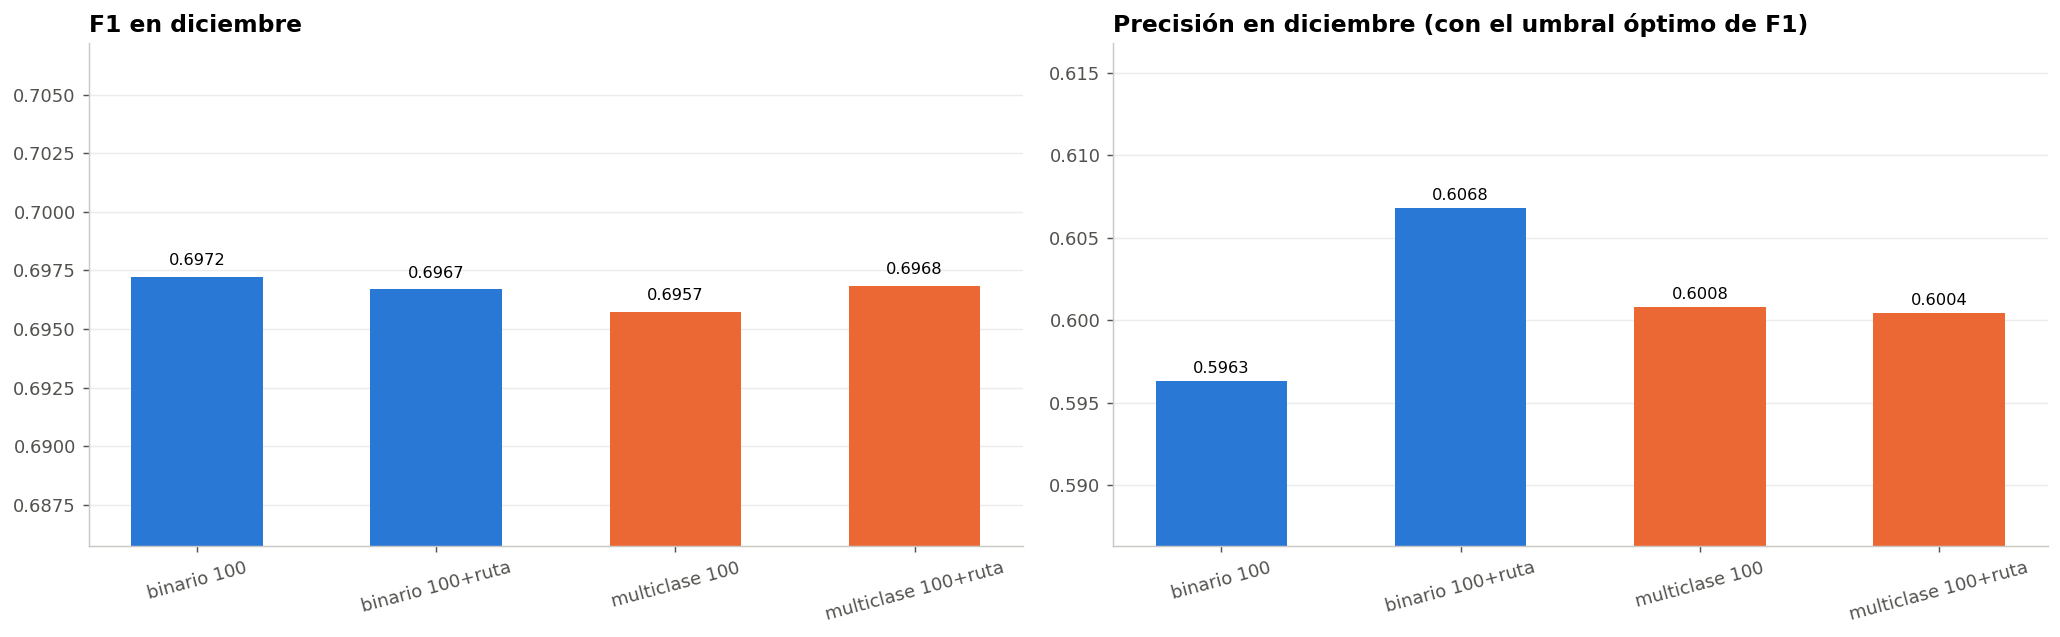

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, col, t in [(axes[0], "F1_dic", "F1 en diciembre"), (axes[1], "precision_dic", "Precisión en diciembre (con el umbral óptimo de F1)")]:
    d = res[col]; ax.bar(d.index, d.values, color=[C_ORANGE if "multiclase" in i else C_BLUE for i in d.index], width=0.55)
    for i, v in enumerate(d.values): ax.text(i, v + 0.0005, f"{v:.4f}", ha="center", fontsize=9)
    ax.set_ylim(d.min() - 0.01, d.max() + 0.01); ax.set_title(t); ax.grid(axis="x", visible=False); ax.tick_params(axis="x", rotation=15)
plt.tight_layout(); fig_cmp = fig; plt.show()

## 4. Resultado y Kaggle

La mejor variante por F1 promedio se reentrena con los cinco meses y califica `oot` con el umbral de diciembre. Archivo `submission_v6.csv`. Se registra como final en MLflow con las métricas de diciembre.

In [6]:
MEJOR = res.F1_prom.idxmax(); cols, mc = VARIANTES[MEJOR]; U = float(res.loc[MEJOR, "umbral_dic"]); n_arb = int(arboles[MEJOR]); cats = [c for c in cols if c in CAT_R]
print(f"Mejor variante: {MEJOR} | F1 prom {res.loc[MEJOR, 'F1_prom']:.4f} | dic {res.loc[MEJOR, 'F1_dic']:.4f} | referencia 07 en dic: 0.6972")
if mc:
    final = lgb.LGBMClassifier(**P, objective="multiclass", num_class=5, n_estimators=n_arb).fit(train[cols], yc, categorical_feature=cats); p_oot = final.predict_proba(test[cols])[:, POS].sum(axis=1)
else:
    final = lgb.LGBMClassifier(**P, objective="binary", n_estimators=n_arb).fit(train[cols], y, categorical_feature=cats); p_oot = final.predict_proba(test[cols])[:, 1]
ss = pd.read_csv(DATA / "sample_submission.csv", usecols=["ID"])
r_ = ss.merge(pd.DataFrame({"ID": test.ID.astype(str), "Prob_uno": p_oot}), on="ID", how="left"); r_["var_rpta_alt"] = (r_.Prob_uno >= U).astype(int); assert r_.Prob_uno.notna().all()
r_[["ID", "var_rpta_alt"]].to_csv(OUT / "submission_v6.csv", index=False); r_[["ID", "var_rpta_alt", "Prob_uno"]].round({"Prob_uno": 5}).to_csv(OUT / "resultado_prueba_v6.csv", index=False, encoding="utf-8")
final.booster_.save_model(str(ROOT / "models" / "lgbm_v6.txt")); pd.Series(cols, name="feature").to_csv(PROC / "features_v6.csv", index=False)
pd.concat([train[KEYS + RUTA], test[KEYS + RUTA]]).to_parquet(PROC / "ruta_features.parquet", index=False)
rid = registrar_final({"variante": MEJOR, "multiclase": mc, "n_vars": len(cols), **{k: v for k, v in P.items() if k not in ("subsample_freq", "random_state", "verbose", "n_jobs")}},
                      {"f1_val": res.loc[MEJOR, "F1_prom"], "f1_dic": res.loc[MEJOR, "F1_dic"], "auc_dic": res.loc[MEJOR, "AUC_dic"], "precision_dic": res.loc[MEJOR, "precision_dic"], "recall_dic": res.loc[MEJOR, "recall_dic"], "n_arboles": n_arb, "pct_pred_1_oot": r_.var_rpta_alt.mean()},
                      U, cols, modelo=final, flavor="lightgbm", ruta_modelo=ROOT / "models" / "lgbm_v6.txt", figuras={"comparacion": fig_cmp}, tags={"ganador_09": "True"})
import mlflow; mlflow.log_artifact(str(OUT / "submission_v6.csv"), artifact_path="kaggle")
g.__exit__(None, None, None)
print(f"Final: {MEJOR} | {n_arb} árboles | umbral {U:.2f} | % predicho 1 en oot: {r_.var_rpta_alt.mean():.3f}")
resumen("grupo")[["run", "f1_val", "f1_dic", "f1_kaggle_publico"]].tail(5)

Mejor variante: binario 100+ruta | F1 prom 0.7048 | dic 0.6967 | referencia 07 en dic: 0.6972


Final: binario 100+ruta | 949 árboles | umbral 0.35 | % predicho 1 en oot: 0.616


,run,f1_val,f1_dic,f1_kaggle_publico
10,07_lgbm_temporal,0.704230,0.697219,NaN
11,07_xgb_temporal,0.703339,0.696438,NaN
12,07_xgb_temporal,NaN,NaN,NaN
13,08_importancia,0.704125,0.698318,NaN
14,09_multiclase_ruta,0.704751,0.696698,NaN
